# Pandas 실습2

### 1. 데이터 준비

In [1]:
import warnings
warnings.filterwarnings(action='ignore')

import pandas as pd
import numpy as np

In [12]:
df1 = pd.read_csv('data/서울특별시 공공자전거 일별 대여건수_25.7-12.csv')
df

,대여일자,대여건수
0,2025-07-01,132914
1,2025-07-02,151653
2,2025-07-03,151092
3,2025-07-04,151367
4,2025-07-05,118354
...,...,...
179,2025-12-27,42381
180,2025-12-28,40774
181,2025-12-29,66652
182,2025-12-30,71026


In [14]:
df2 = pd.read_excel('data/대여소별 대여내역(2017년).xlsx')
df2

,대여소 그룹,대여소 명,대여 일자 / 월,대여 건수
0,그룹명 없음,대여소명 없음,2017-01-01,0
1,광진구,500. 어린이대공원역 3번출구 앞,2017-01-01,20
2,광진구,501. 광진구의회 앞,2017-01-01,10
3,광진구,502. 뚝섬유원지역 1번출구 앞,2017-01-01,9
4,광진구,503. 더샵스타시티 C동 앞,2017-01-01,9
...,...,...,...,...
245441,중랑구,1442. (구)신한은행 중랑교지점,2017-12-31,3
245442,중랑구,1445. 용마지구대,2017-12-31,1
245443,중랑구,1446. 중랑전화국 교차로,2017-12-31,3
245444,중랑구,1447. 면목역 3번출구,2017-12-31,1


In [20]:
# df1의 일자별 대여건수 top10
df1.shape
df1['대여일자'].dtypes

dtype('O')

In [24]:
# '대여일자'의 데이터타입 변환, astype()
df1['대여일자'] = pd.to_datetime(df1['대여일자'])
df1.dtypes
df1['Year'] = df1['대여일자'].dt.year
df1['Month'] = df1['대여일자'].dt.month
df1['Day'] = df1['대여일자'].dt.day
df1

,대여일자,대여건수,Year,Month,Day
0,2025-07-01,132914,2025,7,1
1,2025-07-02,151653,2025,7,2
2,2025-07-03,151092,2025,7,3
3,2025-07-04,151367,2025,7,4
4,2025-07-05,118354,2025,7,5
...,...,...,...,...,...
179,2025-12-27,42381,2025,12,27
180,2025-12-28,40774,2025,12,28
181,2025-12-29,66652,2025,12,29
182,2025-12-30,71026,2025,12,30


In [26]:
df1['Month'].value_counts()

Month
7     31
8     31
10    31
12    31
9     30
11    30
Name: count, dtype: int64

In [32]:
# df1의 2025년도 월별 대여건수
df1_rentals = df1.groupby('Month')['Month'].sum()
df1_rentals.values

array([217, 248, 270, 310, 330, 372], dtype=int32)

In [33]:
import matplotlib.pyplot as plt
import matplotlib

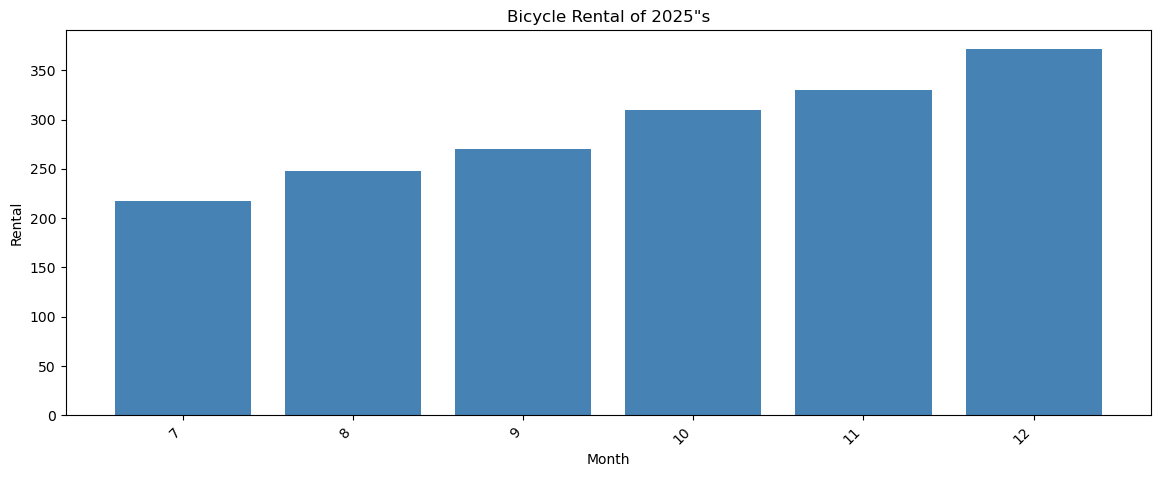

In [38]:
plt.figure(figsize=(14, 5))
plt.bar(df1_rentals.index, df1_rentals.values, color='steelblue')
plt.title('Bicycle Rental of 2025"s')
plt.xlabel('Month')
plt.ylabel('Rental')
plt.xticks(rotation=45, ha='right')
plt.tight_layout
plt.show()

In [39]:
# df2의 대요소별 대여건수 top5
df2.shape

(245446, 4)

In [40]:
df2.dtypes

대여소 그룹               object
대여소 명                object
대여 일자 / 월    datetime64[ns]
대여 건수                 int64
dtype: object

In [44]:
df2['Year'] = df2['대여 일자 / 월'].dt.year
df2['Month'] = df2['대여 일자 / 월'].dt.month
df2['Day'] = df2['대여 일자 / 월'].dt.day
print(df2['Year'])
print('-'*20)
print(df2['Month'])
print('-'*20)
print(df2['Day'])

0         2017
1         2017
2         2017
3         2017
4         2017
          ... 
245441    2017
245442    2017
245443    2017
245444    2017
245445    2017
Name: Year, Length: 245446, dtype: int32
--------------------
0          1
1          1
2          1
3          1
4          1
          ..
245441    12
245442    12
245443    12
245444    12
245445    12
Name: Month, Length: 245446, dtype: int32
--------------------
0          1
1          1
2          1
3          1
4          1
          ..
245441    31
245442    31
245443    31
245444    31
245445    31
Name: Day, Length: 245446, dtype: int32


In [46]:
df2_rental = df2.groupby('Month')['Month'].sum()
df2_rental

Month
1      13059
2      24270
3      41223
4      54104
5      81110
6     112032
7     150794
8     200000
9     238176
10    277030
11    303490
12    357504
Name: Month, dtype: int32

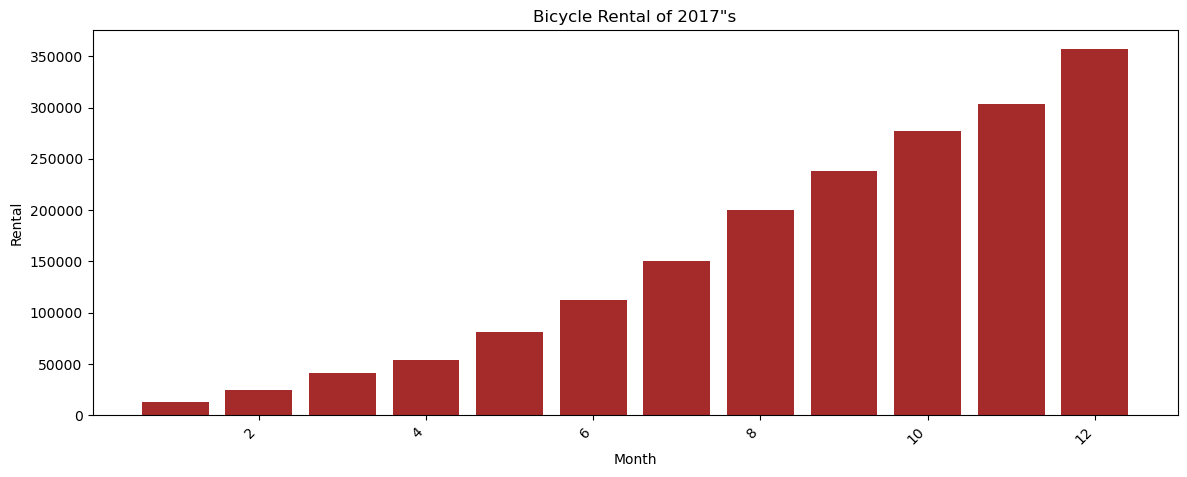

In [47]:
plt.figure(figsize=(14, 5))
plt.bar(df2_rental.index, df2_rental.values, color='brown')
plt.title('Bicycle Rental of 2017"s')
plt.xlabel('Month')
plt.ylabel('Rental')
plt.xticks(rotation=45, ha='right')
plt.tight_layout
plt.show()